In [271]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [272]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [273]:
print(f'Shape of  dataset: {df.shape[0]} rows and {df.shape[1]} columns')
print(f'Columns of dataset: {list(df.columns)}')
missing = df.isnull().sum()
print(f'Missing values in dataset: {missing.sum()}')
duplicates = df.duplicated().sum()
print(f'Duplicate values in dataset: {duplicates.sum()}')


Shape of  dataset: 1338 rows and 7 columns
Columns of dataset: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
Missing values in dataset: 0
Duplicate values in dataset: 1


In [274]:
for col in df.columns:
    if df[col].dtype == 'str':
        unique_values = df[col].unique()
        print(f"CATEGORICAL - {col}:")
        print(f"Unique Values: {unique_values}")
    else:
        col_min = df[col].min()
        col_max = df[col].max()
        print(f"NUMERICAL - {col}:")
        print(f"Range: {col_min} to {col_max}")
    print("-" * 30)

    # print(df.describe(include='str'))

NUMERICAL - age:
Range: 18 to 64
------------------------------
CATEGORICAL - sex:
Unique Values: <StringArray>
['female', 'male']
Length: 2, dtype: str
------------------------------
NUMERICAL - bmi:
Range: 15.96 to 53.13
------------------------------
NUMERICAL - children:
Range: 0 to 5
------------------------------
CATEGORICAL - smoker:
Unique Values: <StringArray>
['yes', 'no']
Length: 2, dtype: str
------------------------------
CATEGORICAL - region:
Unique Values: <StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str
------------------------------
NUMERICAL - charges:
Range: 1121.8739 to 63770.42801
------------------------------


In [275]:
df.drop_duplicates(keep="first",inplace=True)
df.count()

age         1337
sex         1337
bmi         1337
children    1337
smoker      1337
region      1337
charges     1337
dtype: int64

# One-Hot Encoding

In [276]:
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})
df = pd.get_dummies(df, columns=['region'], drop_first=True).astype(int)
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27,0,1,16884,0,0,1
1,18,1,33,1,0,1725,0,1,0
2,28,1,33,3,0,4449,0,1,0
3,33,1,22,0,0,21984,1,0,0
4,32,1,28,0,0,3866,1,0,0


# Checking Outliers

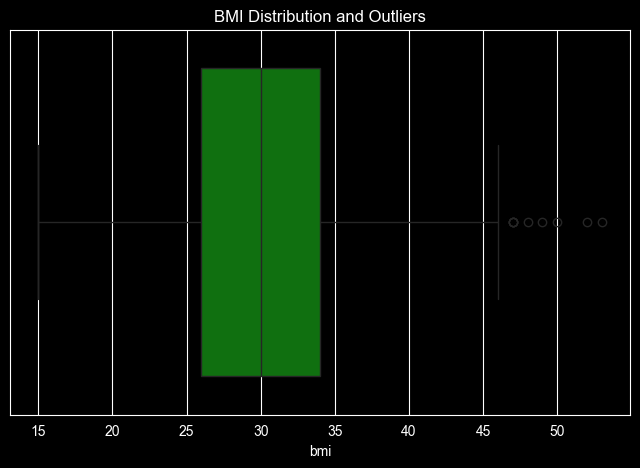

In [277]:
# Checking for outliers in BMI
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['bmi'], color='green')
plt.title('BMI Distribution and Outliers')
plt.show()

Text(0.5, 1.0, 'Original Charges')

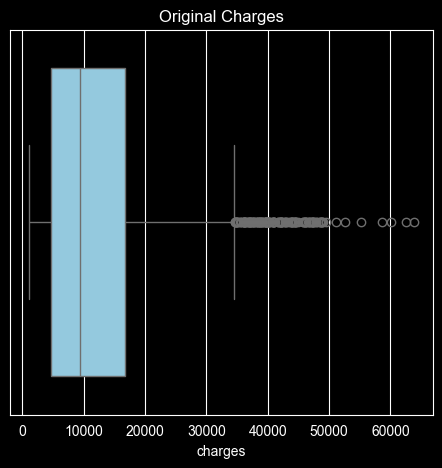

In [278]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['charges'], color='skyblue')
plt.title('Original Charges')

In [279]:
# log-transformed charges column
# df['charges'] = np.log1p(df['charges'])
#
# plt.figure(figsize=(12, 5))
# plt.subplot(1, 2, 2)
# sns.boxplot(x=df['charges'], color='salmon')
# plt.title('Log Charges (Balanced)')
# plt.tight_layout()
# plt.show()

In [280]:
df = df[df['bmi'] < 47]
df.count()

age                 1328
sex                 1328
bmi                 1328
children            1328
smoker              1328
charges             1328
region_northwest    1328
region_southeast    1328
region_southwest    1328
dtype: int64

# Modeling

## Train-Test Split

In [281]:
X = df.drop('charges', axis=1)
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scaling

In [282]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'X_test_scaled shape: {X_test_scaled.shape}')


X_train_scaled shape: (1062, 8)
X_test_scaled shape: (266, 8)


## Model Training

In [283]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print(f'Coefficient:{model.coef_}')
print(f'Intercept:{model.intercept_}')

Coefficient:[3646.7281156   -17.17664766 2073.04390626  644.54549611 9643.40119517
 -248.01967512 -583.11987582 -673.95950667]
Intercept:13244.574387947268


## Evaluations

In [284]:
y_pred = model.predict(X_test_scaled)

In [285]:
residuals = y_test - y_pred
results = pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : y_pred,
    "Residual" : residuals
})
print(results.head())

      Actual     Predicted      Residual
1210    5373   7717.054481  -2344.054481
115    30259  13278.068462  16980.931538
986     8410  10592.814377  -2182.814377
176     6455   7721.365672  -1266.365672
63      4133   3937.229522    195.770478


In [286]:
MAE = mean_absolute_error(y_test, y_pred)
R2 = r2_score(y_test, y_pred)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'MAE : {MAE}\nR2: {R2 : .4f}\nRMSE: {RMSE : .2f}')

MAE : 4126.980482466977
R2:  0.7448
RMSE:  5955.91


# Plots

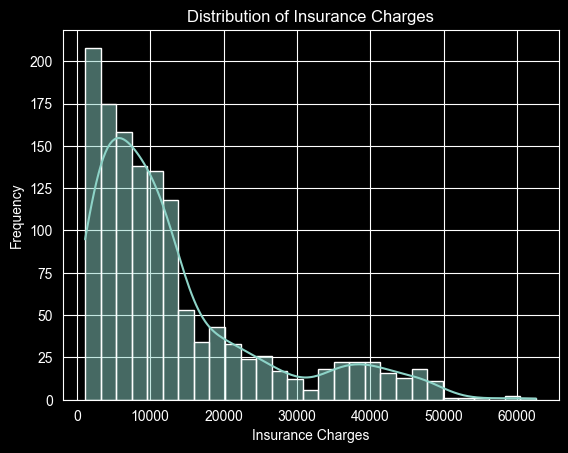

In [287]:
plt.figure()
sns.histplot(y, kde=True)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Insurance Charges")
plt.ylabel("Frequency")
plt.show()

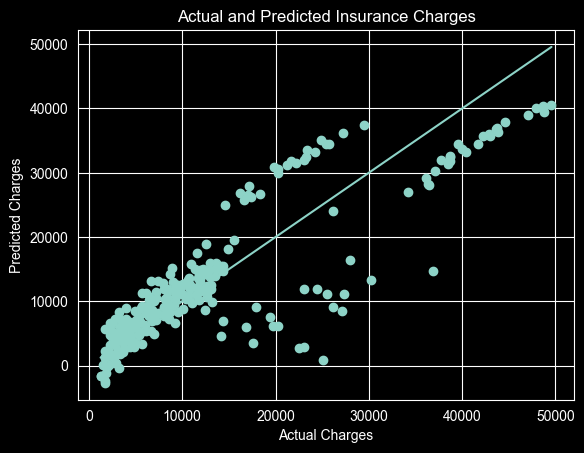

In [288]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual and Predicted Insurance Charges")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
)
plt.show()